#### Import

In [1]:
import sys
import torch
sys.path.insert(0, '..')
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import compute_class_weights, train_with_early_stopping, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.gnn.losses import FocalLoss
from src.gnn.models import GAT

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt', undirected=False)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define model

In [4]:
model = GAT(
    in_channels=data.x.shape[1], 
    hidden_channels=64,
    out_channels=2, 
    heads=2,      
    dropout=0.5
).to(device)

print(model)

GAT(
  (conv1): GATv2Conv(165, 64, heads=2)
  (conv2): GATv2Conv(128, 2, heads=1)
)


#### Focal Loss and Optimizer

In [5]:
weight = compute_class_weights(data, device)

criterion = torch.nn.CrossEntropyLoss(weight=weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model=model, 
    data=data, 
    optimizer=optimizer, 
    criterion=criterion, 
    save_path='../saved_models/gat_best.pt', 
    num_epochs=200, 
    patience=20,
    clip_grad_norm=1.0 
)

Epoch 001: Train Loss=1.1761, Train F1=0.3917, Val F1=0.4059, Gap=-0.0142
Epoch 002: Train Loss=0.9140, Train F1=0.5002, Val F1=0.4384, Gap=0.0618
Epoch 003: Train Loss=0.7771, Train F1=0.5457, Val F1=0.4311, Gap=0.1146
Epoch 004: Train Loss=0.7782, Train F1=0.5648, Val F1=0.4301, Gap=0.1347
Epoch 005: Train Loss=0.6977, Train F1=0.5228, Val F1=0.4162, Gap=0.1066
Epoch 006: Train Loss=0.6488, Train F1=0.4822, Val F1=0.4076, Gap=0.0746
Epoch 007: Train Loss=0.6184, Train F1=0.4711, Val F1=0.4096, Gap=0.0616
Epoch 008: Train Loss=0.5921, Train F1=0.4908, Val F1=0.4196, Gap=0.0713
Epoch 009: Train Loss=0.5774, Train F1=0.5295, Val F1=0.4373, Gap=0.0922
Epoch 010: Train Loss=0.5686, Train F1=0.5527, Val F1=0.4455, Gap=0.1073
Epoch 011: Train Loss=0.5607, Train F1=0.5389, Val F1=0.4289, Gap=0.1100
Epoch 012: Train Loss=0.5394, Train F1=0.5019, Val F1=0.4078, Gap=0.0941
Epoch 013: Train Loss=0.5162, Train F1=0.4762, Val F1=0.3950, Gap=0.0812
Epoch 014: Train Loss=0.5154, Train F1=0.4732, Val

#### Learning curve

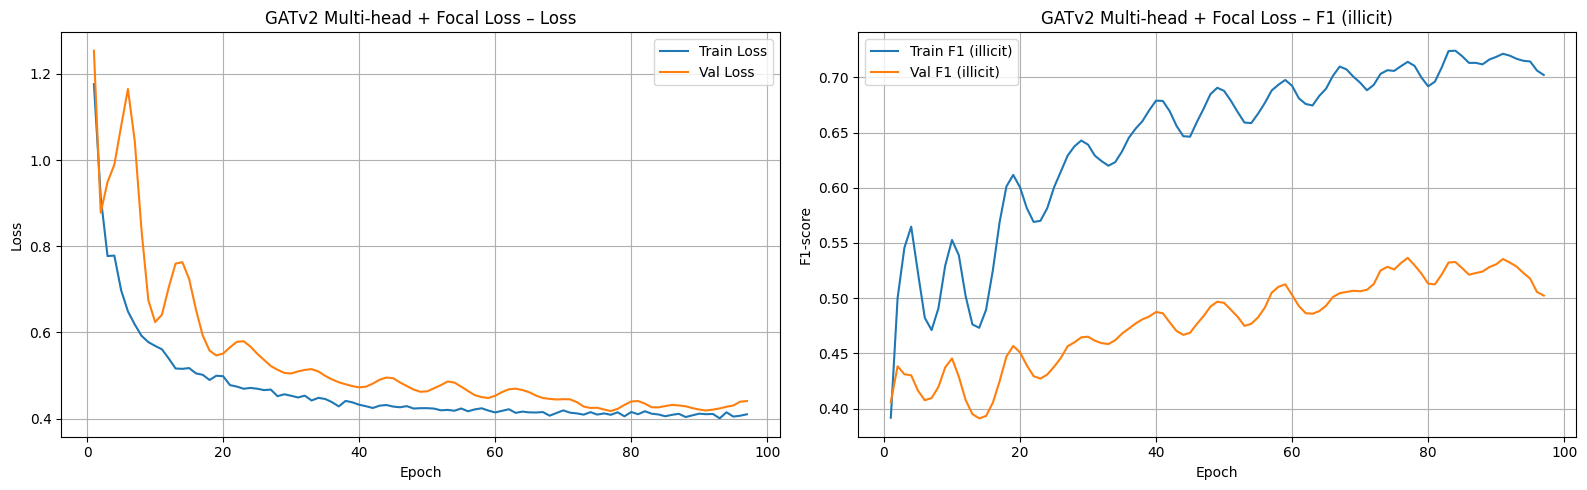

In [7]:
plot_learning_curves(history, model_name="GATv2 Multi-head + Focal Loss")

#### Threshold ablation

In [11]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch.nn.functional as F

model.load_state_dict(torch.load('../saved_models/gat_best.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1]

print("Dò tìm Fine-grained Threshold trên tập Validation:")
best_thresh = 0.70
best_f1 = 0.0

for thresh in np.arange(0.70, 0.81, 0.01):
    preds = (probs[data.val_mask] > thresh).long()
    f1 = f1_score(data.y[data.val_mask].cpu(), preds.cpu(), pos_label=1, zero_division=0)
    print(f"thresh={thresh:.2f}, Val F1(ill)={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest threshold tối ưu tìm được: {best_thresh:.2f} (Val F1 = {best_f1:.4f})")

print(f" GAT Test Set Evaluation (sử dụng Threshold = {best_thresh:.2f})")
print("="*60)

preds_test = (probs[data.test_mask] > best_thresh).long()
y_true_test = data.y[data.test_mask].cpu()
y_pred_test = preds_test.cpu()

print("\nClassification Report:")
print(classification_report(
    y_true_test,
    y_pred_test,
    target_names=["Licit (0)", "Illicit (1)"],
    digits=4,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_test, y_pred_test))


Dò tìm Fine-grained Threshold trên tập Validation:
thresh=0.70, Val F1(ill)=0.7359
thresh=0.71, Val F1(ill)=0.7422
thresh=0.72, Val F1(ill)=0.7426
thresh=0.73, Val F1(ill)=0.7375
thresh=0.74, Val F1(ill)=0.7219
thresh=0.75, Val F1(ill)=0.6930
thresh=0.76, Val F1(ill)=0.6713
thresh=0.77, Val F1(ill)=0.6418
thresh=0.78, Val F1(ill)=0.6169
thresh=0.79, Val F1(ill)=0.5965
thresh=0.80, Val F1(ill)=0.5599
thresh=0.81, Val F1(ill)=0.5055

Best threshold tối ưu tìm được: 0.72 (Val F1 = 0.7426)
 GAT Test Set Evaluation (sử dụng Threshold = 0.72)

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9652    0.9396    0.9522     15587
 Illicit (1)     0.3710    0.5125    0.4304      1083

    accuracy                         0.9119     16670
   macro avg     0.6681    0.7260    0.6913     16670
weighted avg     0.9266    0.9119    0.9183     16670


Confusion Matrix:
[[14646   941]
 [  528   555]]
